# LunarLander Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的作用是先让读者看到：如果在 LunarLander 这种多目标耦合控制任务里完全随机地选择动作，结果通常会有多差。这个 baseline 用来给后面的 `PPO` 实验提供最直观的参照。

## 环境背景

LunarLander 是一个经典的登月着陆控制任务。智能体需要控制着陆器在重力作用下逐步减速、修正横向偏移、调整姿态，并尽量平稳地落在指定着陆区域。离散动作版本通常包含四类动作：

- 不点火
- 左侧姿态推进
- 主发动机点火
- 右侧姿态推进

这个任务难在多个控制目标耦合在一起：下降速度、横向位置、机身角度和接地状态会同时影响结果。

## 方法说明

这里的方法就是纯随机动作采样：每一步直接从动作空间中随机采样，不维护价值函数，也不更新策略。它不是正式算法，但它能够非常直观地说明这个环境为什么不能靠随机行为解决。

## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "LunarLander-v3"
NUM_EPISODES = 500
MAX_STEPS = 1000
DEMO_EPISODES = 3
DEMO_FPS = 30
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

## 参数选择说明

- `NUM_EPISODES = 500`：LunarLander 单回合比 FrozenLake 长，500 回合足够看出随机策略的典型表现
- `MAX_STEPS = 1000`：给着陆器足够长的回合上限，避免因为过早截断干扰统计结果
- `DEMO_EPISODES = 3`：保存 3 个不同初始化 seed 的随机回放，便于直观看到随机控制的典型失败形态

这个 notebook 的重点不是训练，而是建立一个合理的随机控制基线。

In [3]:
episode_rewards = []
episode_lengths = []
successful_landings = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if terminated or truncated:
            episode_lengths.append(step + 1)
            successful_landings.append(int(total_reward >= 200))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successful_landings.append(0)

    episode_rewards.append(total_reward)

env.close()

Random episodes:   0%|          | 0/500 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "successful_landing": successful_landings,
    }
)
summary.describe(include="all")

,reward,episode_length,successful_landing
count,500.000000,500.000000,500.0
mean,-178.836573,93.318000,0.0
std,111.768729,45.270738,0.0
min,-579.416564,57.000000,0.0
25%,-251.621943,76.000000,0.0
50%,-146.347589,91.000000,0.0
75%,-100.739725,104.000000,0.0
max,41.384137,1000.000000,0.0


In [5]:
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
landing_rate = float(np.mean(successful_landings))

metrics = pd.DataFrame(
    {
        "metric": ["average_reward", "average_episode_length", "successful_landing_rate"],
        "value": [avg_reward, avg_length, landing_rate],
    }
)
metrics

,metric,value
0,average_reward,-178.836573
1,average_episode_length,93.318000
2,successful_landing_rate,0.000000


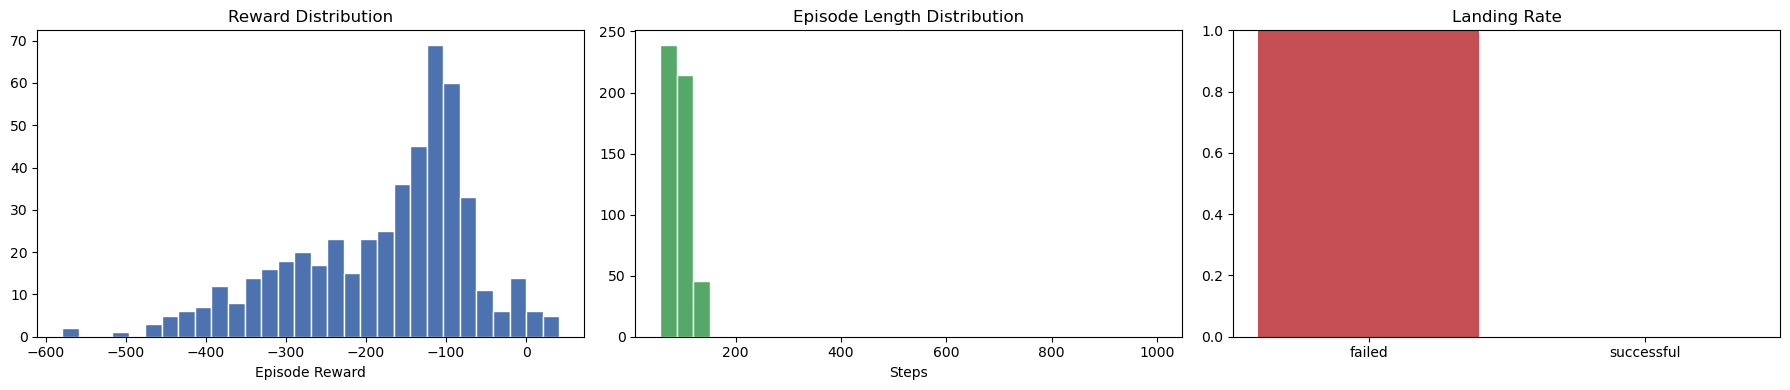

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(["failed", "successful"], [1 - landing_rate, landing_rate], color=["#c44e52", "#8172b3"])
axes[2].set_title("Landing Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
demo_summaries = []
for demo_idx in range(DEMO_EPISODES):
    demo_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = demo_env.reset(seed=SEED + 1000 + demo_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = demo_env.render()
        if frame is not None:
            frames.append(frame)

        action = demo_env.action_space.sample()
        obs, reward, terminated, truncated, info = demo_env.step(action)
        total_reward += reward
        if terminated or truncated:
            final_frame = demo_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            demo_summaries.append(
                {
                    "demo_index": demo_idx,
                    "seed": SEED + 1000 + demo_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    demo_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_demo_{demo_idx + 1}.gif", frames, fps=DEMO_FPS)

metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
pd.DataFrame(demo_summaries).to_csv(RESULTS_DIR / "random_baseline_demo_summary.csv", index=False)

print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Successful landing rate: {landing_rate:.4f}")
print("Saved 3 random baseline demo GIFs with different initialization seeds.")
print(f"Saved results to: {RESULTS_DIR.resolve()}")

Average reward: -178.84
Average episode length: 93.32
Successful landing rate: 0.0000
Saved 3 random baseline demo GIFs with different initialization seeds.
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/16-lunarlander-ppo/results


## 结果解读

随机控制在 LunarLander 里通常会表现得很差，平均回报往往为负，真正稳定着陆的比例非常低。这说明这个任务的核心难点不在于“偶然做对一个动作”，而在于必须持续做一串协调决策。